# HIER-GNN v3 — Version finale PFE (sans data leakage)

```
DATABASE → DATA PREPROCESSING
    ↓                              ↓
Activity-Knowledge Graph    Student-Activity Interaction Graph
(cefr+unit+task+            (task + grammar + vocabulary + reading)
 grammar+vocabulary+reading)
    ↓                              ↓
HeteroGAT_KG (3 couches)   Dynamic Sub-Graph (K_RECENT=20)
    ↓                        ExponentialForgetting multi-types
Task/Grammar/Vocab/Read            ↓
Embeddings               Student Embedding
    ↓                              ↓
         Hierarchical Filtering (CEFR N, N+1)
                       ↓
    Prediction Layer (cosinus + température)
                       ↓
  Recommendation Results (task + grammar + vocab + reading)
```

**Corrections appliquées :**

| # | Problème | Fix |
|---|---|---|
| F1 | LOO n==1 : cold user dans dynamic | exclus du dynamic |
| F2 | ExponentialForgetting collapse | tw_min=0.1 + /sqrt(N) + LayerNorm |
| F3 | make_g2_multi : grammar/vocab/read non filtrés | filtre temporel strict |
| F4 | Pas de diversité dans la loss | uniformity loss λ=0.1 |
| F5 | Pas de diagnostic collapse | stu_std affiché chaque eval |


In [1]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


## §0. Installation

In [2]:
!pip install torch torch_geometric scikit-learn pandas matplotlib -q
print('✓ Prêt')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.2 MB/s eta 0:00:00
✓ Prêt


## §1. Imports & Configuration

In [3]:
import os, copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch_geometric.data import HeteroData
from torch_geometric.nn import GATConv, HeteroConv, Linear
from collections import defaultdict, Counter
import warnings
warnings.filterwarnings('ignore')

# ── Configuration ──────────────────────────────────────────
CEFR_ORDER  = ['A1', 'A2', 'B1', 'B2', 'C1', 'C2']
CEFR_TO_IDX = {c: i for i, c in enumerate(CEFR_ORDER)}
MU          = 0.01697884130961766   # ← Optuna best
K_RECENT    = 20
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED        = 42
torch.manual_seed(SEED)

print(f'✓ Device       : {DEVICE}')
print(f'✓ MU Ebbinghaus: {MU}')
print(f'✓ K_RECENT     : {K_RECENT}')


✓ Device       : cuda
✓ MU Ebbinghaus: 0.01697884130961766
✓ K_RECENT     : 20


## §2. Chargement des données

In [4]:
BASE = '/content/drive/MyDrive/pfe/'

print('[1/7] Chargement...')

kg      = torch.load(BASE + 'data.pt',         map_location='cpu', weights_only=False)
g2_base = torch.load(BASE + 'student_data_multi.pt', map_location='cpu', weights_only=False)

N_STU  = g2_base['student'].x.shape[0]
N_TASK = kg['task'].x.shape[0]
N_GRAM = kg['grammar'].x.shape[0]
N_VOC  = kg['vocabulary'].x.shape[0]
N_READ = kg['reading'].x.shape[0]

# ── FIX 1 : act_to_task.pt — construit automatiquement si absent ──────────
act_to_task_path = BASE + 'act_to_task.pt'
if os.path.exists(act_to_task_path):
    act_to_task = torch.load(act_to_task_path, map_location='cpu')
    print('  act_to_task.pt  : chargé')
else:
    act_node_ids = g2_base['activity'].node_id
    task_nids    = list(kg['task'].node_id)
    mapping = []
    for aid in act_node_ids:
        gidx  = int(aid)
        found = next((j for j, tnid in enumerate(task_nids)
                      if tnid.endswith(f'_{gidx}')), 0)
        mapping.append(found)
    act_to_task = torch.tensor(mapping, dtype=torch.long)
    torch.save(act_to_task, act_to_task_path)
    print(f'  act_to_task.pt  : construit ({len(mapping)} activités mappées)')

# ── FIX 1 : student_data_multi.pt — construit automatiquement si absent ───
multi_path = BASE + 'student_data_multi.pt'
if os.path.exists(multi_path):
    g2_raw = torch.load(multi_path, map_location='cpu', weights_only=False)
    print('  student_data_multi.pt : chargé')
else:
    print('  Construction student_data_multi.pt...')

    # Interactions task : remap activity local idx → task KG idx
    ei_act = g2_base['student', 'attempted', 'activity'].edge_index
    ea_act = g2_base['student', 'attempted', 'activity'].edge_attr
    ei_task = ei_act.clone()
    valid   = ei_act[1] < len(act_to_task)
    ei_task[1, valid] = act_to_task[ei_act[1, valid]]

    g2_raw = HeteroData()
    g2_raw['student'].x    = g2_base['student'].x
    g2_raw['student'].node_id  = g2_base['student'].node_id
    g2_raw['student'].cefr     = g2_base['student'].cefr
    g2_raw['student'].level    = g2_base['student'].level

    g2_raw['student', 'attempted', 'task'].edge_index = ei_task
    g2_raw['student', 'attempted', 'task'].edge_attr  = ea_act

    # Interactions virtuelles grammar/vocabulary/reading
    # Propagées depuis task → nœuds adjacents dans le KG
    def propagate_interactions(ei_task_src, ea_task, kg, rel, dst_type, max_per_stu=10):
        """Crée des arêtes student→dst_type via task→dst_type dans le KG"""
        if ('task', rel, dst_type) not in kg.edge_types:
            return torch.zeros(2, 0, dtype=torch.long), torch.zeros(0, ea_task.shape[1])
        ei_kg = kg['task', rel, dst_type].edge_index  # [2, E_kg]
        task_to_dst = defaultdict(list)
        for t, d in zip(ei_kg[0].tolist(), ei_kg[1].tolist()):
            task_to_dst[t].append(d)
        src_list, dst_list, attr_list = [], [], []
        stu_count = defaultdict(int)
        for i in range(ei_task_src.shape[1]):
            s = ei_task_src[0, i].item()
            t = ei_task_src[1, i].item()
            if stu_count[s] >= max_per_stu:
                continue
            for d in task_to_dst.get(t, []):
                src_list.append(s)
                dst_list.append(d)
                attr_list.append(ea_task[i])
                stu_count[s] += 1
        n_truncated = sum(1 for v in stu_count.values() if v >= max_per_stu)
        if n_truncated > 0:
            print(f"    WARNING: {n_truncated} etudiants tronques a max_per_stu={max_per_stu}")
        if not src_list:
            return torch.zeros(2, 0, dtype=torch.long), torch.zeros(0, ea_task.shape[1])
        ei_out = torch.tensor([src_list, dst_list], dtype=torch.long)
        ea_out = torch.stack(attr_list)
        return ei_out, ea_out

    ei_g, ea_g = propagate_interactions(ei_task, ea_act, kg, 'uses_grammar',    'grammar')
    ei_v, ea_v = propagate_interactions(ei_task, ea_act, kg, 'uses_vocab',      'vocabulary')
    ei_r, ea_r = propagate_interactions(ei_task, ea_act, kg, 'uses_reading',    'reading')

    g2_raw['student', 'practiced', 'grammar'].edge_index    = ei_g
    g2_raw['student', 'practiced', 'grammar'].edge_attr     = ea_g
    g2_raw['student', 'studied',   'vocabulary'].edge_index = ei_v
    g2_raw['student', 'studied',   'vocabulary'].edge_attr  = ea_v
    g2_raw['student', 'read',      'reading'].edge_index    = ei_r
    g2_raw['student', 'read',      'reading'].edge_attr     = ea_r

    torch.save(g2_raw, multi_path)
    print(f'  student_data_multi.pt : construit et sauvegardé')

ei_task_raw = g2_raw['student', 'attempted',  'task'].edge_index
ea_task_raw = g2_raw['student', 'attempted',  'task'].edge_attr
ei_gram     = g2_raw['student', 'practiced',  'grammar'].edge_index
ea_gram     = g2_raw['student', 'practiced',  'grammar'].edge_attr
ei_voc      = g2_raw['student', 'studied',    'vocabulary'].edge_index
ea_voc      = g2_raw['student', 'studied',    'vocabulary'].edge_attr
ei_read     = g2_raw['student', 'read',       'reading'].edge_index
ea_read     = g2_raw['student', 'read',       'reading'].edge_attr

print(f'\n  Etudiants       : {N_STU:,}')
print(f'  Tasks           : {N_TASK}')
print(f'  Grammar         : {N_GRAM:,}')
print(f'  Vocabulary      : {N_VOC:,}')
print(f'  Reading         : {N_READ:,}')
print(f'  Inter. task     : {ei_task_raw.shape[1]:,}')
print(f'  Inter. grammar  : {ei_gram.shape[1]:,}')
print(f'  Inter. vocab    : {ei_voc.shape[1]:,}')
print(f'  Inter. reading  : {ei_read.shape[1]:,}')


[1/7] Chargement...
  act_to_task.pt  : chargé
  student_data_multi.pt : chargé

  Etudiants       : 89,589
  Tasks           : 128
  Grammar         : 1,218
  Vocabulary      : 7,459
  Reading         : 9,565
  Inter. task     : 404,773
  Inter. grammar  : 2,023,865
  Inter. vocab    : 1,997,660
  Inter. reading  : 2,023,865


✓ [attempted  task        ]   404773 interactions | poids moy=0.1300  min=0.1000  max=1.0000
✓ [practiced  grammar     ]  2023865 interactions | poids moy=0.1300  min=0.1000  max=1.0000
✓ [studied    vocabulary  ]  1997660 interactions | poids moy=0.1294  min=0.1000  max=1.0000
✓ [read       reading     ]  2023865 interactions | poids moy=0.1300  min=0.1000  max=1.0000


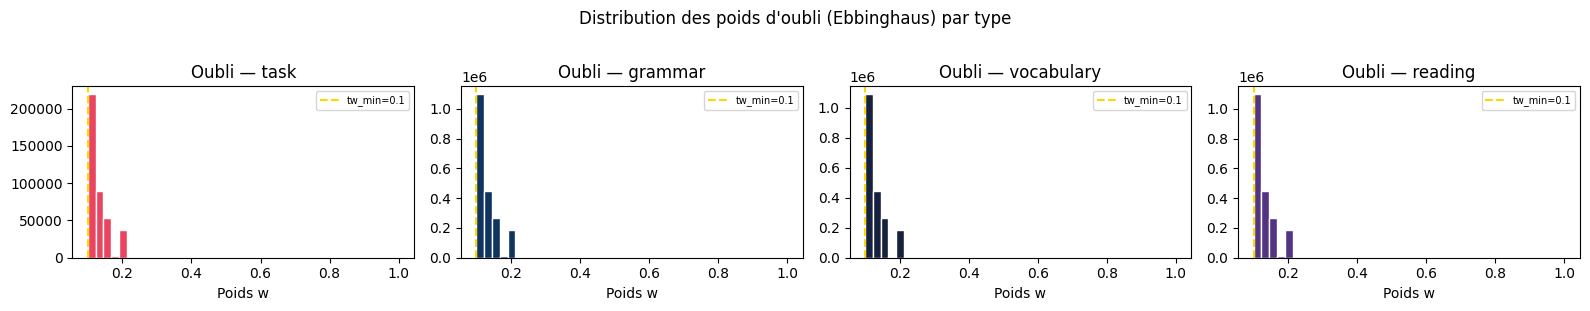

In [5]:
import torch
import matplotlib.pyplot as plt
import copy


TW_MIN = 0.1

# Repartir des tenseurs RAW originaux
raw_data = [
    ('student', 'attempted', 'task',       ei_task_raw, ea_task_raw),
    ('student', 'practiced', 'grammar',    ei_gram,     ea_gram),
    ('student', 'studied',   'vocabulary', ei_voc,      ea_voc),
    ('student', 'read',      'reading',    ei_read,     ea_read),
]

all_weights = []

for src, rel, dst, ei, ea in raw_data:
    ea = ea.clone().float()

    # ── col1 = timestamp → converti en jours réels ────────────────────
    timestamps    = ea[:, 1]
    delta_t_jours = (timestamps.max() - timestamps) / 0.0039
    weights       = torch.clamp(torch.exp(-MU * delta_t_jours), min=TW_MIN)

    # Normalisation vectorisée par étudiant
    student_ids = ei[0]
    counts      = torch.zeros(student_ids.max() + 1)
    counts.scatter_add_(0, student_ids, torch.ones(len(student_ids)))
    n_per_edge  = counts[student_ids]
    weights     = weights / (n_per_edge.sqrt() + 1e-8)

    # ── CORRECTION : rescaling [TW_MIN, 1.0] par type ─────────────────
    w_min   = weights.min()
    w_max   = weights.max()
    weights = TW_MIN + (weights - w_min) / (w_max - w_min + 1e-8) * (1.0 - TW_MIN)

    # Appliquer le poids sur ea (sauf col1 qu'on garde intacte)
    ea_weighted = ea.clone()
    for col in [0, 2, 3]:
        ea_weighted[:, col] = ea[:, col] * weights

    # Mettre à jour le graphe
    g2_base[(src, rel, dst)].edge_index = ei
    g2_base[(src, rel, dst)].edge_attr  = ea_weighted

    all_weights.append((dst, weights.detach()))

    print(f"✓ [{rel:10s} {dst:12s}] {ei.shape[1]:>8} interactions | "
          f"poids moy={weights.mean():.4f}  min={weights.min():.4f}  max={weights.max():.4f}")

# ── Visualisation ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 3))
colors = ['#e94560', '#0f3460', '#16213e', '#533483']

for ax, (name, w), color in zip(axes, all_weights, colors):
    ax.hist(w.numpy(), bins=40, color=color, edgecolor='white')
    ax.axvline(TW_MIN, color='gold', linestyle='--', label=f'tw_min={TW_MIN}')
    ax.set_title(f"Oubli — {name}")
    ax.set_xlabel("Poids w")
    ax.legend(fontsize=7)

plt.suptitle("Distribution des poids d'oubli (Ebbinghaus) par type", y=1.02)
plt.tight_layout()
plt.show()

## §3. Construction du KG adapté

In [6]:
print('[2/7] Construction KG...')

# CECRL de chaque nœud
def build_cefr_idx(N, ei_cefr_to_node):
    idx = torch.zeros(N, dtype=torch.long)
    for c, n in zip(ei_cefr_to_node[0].tolist(), ei_cefr_to_node[1].tolist()):
        idx[n] = c
    return idx

task_cefr_idx = build_cefr_idx(N_TASK, kg['cefr', 'has_task',    'task'].edge_index)
gram_cefr_idx = build_cefr_idx(N_GRAM, kg['cefr', 'requires',    'grammar'].edge_index)
read_cefr_idx = build_cefr_idx(N_READ, kg['cefr', 'has_reading', 'reading'].edge_index)

# vocabulary — CECRL via has_vocab si disponible
voc_cefr_idx = torch.zeros(N_VOC, dtype=torch.long)
if ('cefr', 'has_vocab', 'vocabulary') in kg.edge_types:
    ei_cv = kg['cefr', 'has_vocab', 'vocabulary'].edge_index
    for c, v in zip(ei_cv[0].tolist(), ei_cv[1].tolist()):
        voc_cefr_idx[v] = c

node_cefr_dict = {
    'task'      : task_cefr_idx,
    'grammar'   : gram_cefr_idx,
    'vocabulary': voc_cefr_idx,
    'reading'   : read_cefr_idx,
}

# Distribution
for nt, cidx in node_cefr_dict.items():
    dist = {CEFR_ORDER[i]: (cidx == i).sum().item() for i in range(6)}
    print(f'  {nt:12s} CECRL: {dist}')

# KG adapté
kg_adapted = HeteroData()
for nt in ['cefr', 'unit', 'task', 'grammar', 'vocabulary', 'reading']:
    kg_adapted[nt].x = kg[nt].x

def add_edge(src, rel, dst):
    et = (src, rel, dst)
    if et in kg.edge_types:
        kg_adapted[et].edge_index = kg[et].edge_index

def add_reverse(src, rel, dst, rev_rel):
    et = (src, rel, dst)
    if et in kg.edge_types:
        ei = kg[et].edge_index
        kg_adapted[dst, rev_rel, src].edge_index = torch.stack([ei[1], ei[0]])

add_edge('cefr', 'progression_to', 'cefr')
add_edge('cefr', 'contains',       'unit')
add_edge('cefr', 'has_task',       'task')
add_edge('cefr', 'requires',       'grammar')
add_edge('cefr', 'has_vocab',      'vocabulary')
add_edge('cefr', 'has_reading',    'reading')
add_edge('unit', 'includes',       'task')
add_edge('unit', 'related_unit',   'unit')
add_edge('task', 'related_task',   'task')

add_reverse('cefr', 'has_task',    'task',       'belongs_to_cefr')
add_reverse('cefr', 'contains',    'unit',       'included_in_cefr')
add_reverse('unit', 'includes',    'task',       'included_in_unit')
add_reverse('cefr', 'requires',    'grammar',    'required_by_cefr')
add_reverse('cefr', 'has_vocab',   'vocabulary', 'vocab_of_cefr')
add_reverse('cefr', 'has_reading', 'reading',    'reading_of_cefr')

print(f'\n  Edge types KG : {len(kg_adapted.edge_types)}')

[2/7] Construction KG...
  task         CECRL: {'A1': 24, 'A2': 24, 'B1': 24, 'B2': 24, 'C1': 24, 'C2': 8}
  grammar      CECRL: {'A1': 109, 'A2': 289, 'B1': 337, 'B2': 242, 'C1': 129, 'C2': 112}
  vocabulary   CECRL: {'A1': 1066, 'A2': 1352, 'B1': 2351, 'B2': 2690, 'C1': 0, 'C2': 0}
  reading      CECRL: {'A1': 724, 'A2': 2911, 'B1': 2268, 'B2': 1787, 'C1': 22, 'C2': 1853}

  Edge types KG : 15


## §4. Split Temporal LOO + Dynamic Sub-Graph

In [7]:
print('[3/7] Split Temporal LOO sans data leakage...')

stu_interactions = defaultdict(list)
for idx in range(ei_task_raw.shape[1]):
    s  = ei_task_raw[0, idx].item()
    a  = ei_task_raw[1, idx].item()
    tw = ea_task_raw[idx, 1].item()
    stu_interactions[s].append((tw, a, idx))

train_idx_list, val_idx_list, test_idx_list, dynamic_idx_list = [], [], [], []
n_cold = 0

for s, interactions in stu_interactions.items():
    interactions.sort(key=lambda x: x[0], reverse=True)
    n = len(interactions)

    if n == 1:
        # FIX : cold user → train seulement, PAS dans dynamic
        # dynamic doit refléter l'historique AVANT le test item
        train_idx_list.append(interactions[0][2])
        n_cold += 1

    elif n == 2:
        # test = interactions[0], train = interactions[1]
        # dynamic = interactions[1] (train strict)
        test_idx_list.append(interactions[0][2])
        train_idx_list.append(interactions[1][2])
        dynamic_idx_list.append(interactions[1][2])

    else:
        # n >= 3 : protocol standard LOO
        # interactions[0] = test, interactions[1] = val
        # interactions[2:] = train, dynamic = train[:K_RECENT]
        test_idx_list.append(interactions[0][2])
        val_idx_list.append(interactions[1][2])
        for _, _, idx in interactions[2:]:
            train_idx_list.append(idx)
        for _, _, idx in interactions[2:2+K_RECENT]:
            dynamic_idx_list.append(idx)

train_idx   = torch.tensor(train_idx_list,   dtype=torch.long)
val_idx     = torch.tensor(val_idx_list,     dtype=torch.long)
test_idx    = torch.tensor(test_idx_list,    dtype=torch.long)
dynamic_idx = torch.tensor(dynamic_idx_list, dtype=torch.long)

# ── Vérification anti-fuite ──────────────────────────────────
val_set     = set(val_idx.tolist())
test_set_s  = set(test_idx.tolist())
dynamic_set = set(dynamic_idx.tolist())

leak_dyn_val  = len(dynamic_set & val_set)
leak_dyn_test = len(dynamic_set & test_set_s)
assert leak_dyn_val  == 0, f"FUITE dynamic∩val  : {leak_dyn_val}"
assert leak_dyn_test == 0, f"FUITE dynamic∩test : {leak_dyn_test}"

print(f'  Train   : {len(train_idx):,}')
print(f'  Val     : {len(val_idx):,}')
print(f'  Test    : {len(test_idx):,}')
print(f'  Dynamic : {len(dynamic_idx):,}  (K={K_RECENT})')
print(f'  Cold    : {n_cold:,}  (exclus du dynamic)')
print(f'  ✅ Aucune fuite dynamic→val/test détectée')


[3/7] Split Temporal LOO sans data leakage...
  Train   : 315,500
  Val     : 37,483
  Test    : 51,790
  Dynamic : 253,029  (K=20)
  Cold    : 37,799  (exclus du dynamic)
  ✅ Aucune fuite dynamic→val/test détectée


## §5. Construction des graphes étudiants multi-types

In [8]:
print('[4/7] Construction graphes étudiants multi-types...')

def make_g2_multi(task_idx, gram_idx=None, voc_idx=None, read_idx=None):
    """
    Graphe étudiant avec task + grammar + vocabulary + reading.
    FIX 3 : grammar/vocab/read filtrés sur les mêmes étudiants
             ET les mêmes interactions temporelles que task_idx.
    """
    g = HeteroData()
    g['student'].x    = g2_raw['student'].x
    g['task'].x       = kg['task'].x
    g['grammar'].x    = kg['grammar'].x
    g['vocabulary'].x = kg['vocabulary'].x
    g['reading'].x    = kg['reading'].x

    # Interactions task (split)
    g['student', 'attempted', 'task'].edge_index = ei_task_raw[:, task_idx]
    g['student', 'attempted', 'task'].edge_attr  = ea_task_raw[task_idx]

    # Étudiants présents dans ce split
    stu_in_split = set(ei_task_raw[0, task_idx].tolist())

    def filter_edges(ei, ea, idx=None):
        """Filtre sur étudiants du split; si idx fourni, filtre par index aussi."""
        if idx is not None:
            ei_f = ei[:, idx]; ea_f = ea[idx]
        else:
            mask = torch.tensor([s.item() in stu_in_split for s in ei[0]], dtype=torch.bool)
            ei_f = ei[:, mask]; ea_f = ea[mask]
        return ei_f, ea_f

    ei_g, ea_g = filter_edges(ei_gram, ea_gram, gram_idx)
    ei_v, ea_v = filter_edges(ei_voc,  ea_voc,  voc_idx)
    ei_r, ea_r = filter_edges(ei_read, ea_read, read_idx)

    g['student', 'practiced', 'grammar'].edge_index    = ei_g
    g['student', 'practiced', 'grammar'].edge_attr     = ea_g
    g['student', 'studied',   'vocabulary'].edge_index = ei_v
    g['student', 'studied',   'vocabulary'].edge_attr  = ea_v
    g['student', 'read',      'reading'].edge_index    = ei_r
    g['student', 'read',      'reading'].edge_attr     = ea_r
    return g


# Pour dynamic : on filtre grammar/vocab/read sur les mêmes étudiants
# que dynamic_idx (train strict seulement)
print('  Construction g2_train...')
g2_train   = make_g2_multi(train_idx)
print('  Construction g2_val...')
g2_val     = make_g2_multi(val_idx)
print('  Construction g2_test...')
g2_test    = make_g2_multi(test_idx)
print('  Construction g2_dynamic...')
g2_dynamic = make_g2_multi(dynamic_idx)

print(f'\n  g2_train   : {g2_train["student","attempted","task"].edge_index.shape[1]:,} tasks')
print(f'  g2_dynamic : {g2_dynamic["student","attempted","task"].edge_index.shape[1]:,} tasks')
print(f'             + {g2_dynamic["student","practiced","grammar"].edge_index.shape[1]:,} grammar')
print(f'             + {g2_dynamic["student","studied","vocabulary"].edge_index.shape[1]:,} vocab')
print(f'             + {g2_dynamic["student","read","reading"].edge_index.shape[1]:,} reading')


[4/7] Construction graphes étudiants multi-types...
  Construction g2_train...
  Construction g2_val...
  Construction g2_test...
  Construction g2_dynamic...

  g2_train   : 315,500 tasks
  g2_dynamic : 253,029 tasks
             + 1,834,870 grammar
             + 1,810,650 vocab
             + 1,834,870 reading


In [ ]:
# ── Sauvegarder tout pour notebook expérimentation ────────────────────
print('Sauvegarde fichiers...')
torch.save(g2_train,   BASE + 'g2_train.pt')
torch.save(g2_test,    BASE + 'g2_test.pt')
torch.save(g2_dynamic, BASE + 'g2_dynamic.pt')
torch.save(kg_adapted, BASE + 'kg_adapted.pt')
print('✅ g2_train.pt')
print('✅ g2_test.pt')
print('✅ g2_dynamic.pt')
print('✅ kg_adapted.pt')

Sauvegarde fichiers...
✅ g2_train.pt
✅ g2_test.pt
✅ g2_dynamic.pt
✅ kg_adapted.pt


## §6. Architecture HIER-GNN v3

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# HIER-GNN v3 — Fix Cold Start inspiré de EGRec
# ══════════════════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────
# Bloc 1 : HeteroGAT_KG (INCHANGÉ)
# ──────────────────────────────────────────────────────────
class HeteroGAT_KG(nn.Module):
    """
    GAT hétérogène complet :
    cefr + unit + task + grammar + vocabulary + reading
    → embeddings pour TOUS les types de nœuds
    """
    def __init__(self, hidden_dim=128, out_dim=64, heads=4, dropout=0.3):
        super().__init__()
        self.proj = nn.ModuleDict({
            'cefr'      : Linear(128, hidden_dim),
            'unit'      : Linear(128, hidden_dim),
            'task'      : Linear(128, hidden_dim),
            'grammar'   : Linear(128, hidden_dim),
            'vocabulary': Linear(128, hidden_dim),
            'reading'   : Linear(128, hidden_dim),
        })
        gat = dict(dropout=dropout, add_self_loops=False)
        h, hh = heads, hidden_dim // heads

        # Couche 1 — propagation large
        self.conv1 = HeteroConv({
            ('cefr',       'progression_to', 'cefr')      : GATConv(hidden_dim, hh, heads=h, **gat),
            ('cefr',       'contains',       'unit')      : GATConv(hidden_dim, hh, heads=h, **gat),
            ('cefr',       'has_task',       'task')      : GATConv(hidden_dim, hh, heads=h, **gat),
            ('cefr',       'requires',       'grammar')   : GATConv(hidden_dim, hh, heads=h, **gat),
            ('cefr',       'has_vocab',      'vocabulary'): GATConv(hidden_dim, hh, heads=h, **gat),
            ('cefr',       'has_reading',    'reading')   : GATConv(hidden_dim, hh, heads=h, **gat),
            ('unit',       'includes',       'task')      : GATConv(hidden_dim, hh, heads=h, **gat),
            ('unit',       'related_unit',   'unit')      : GATConv(hidden_dim, hh, heads=h, **gat),
            ('task',       'belongs_to_cefr','cefr')      : GATConv(hidden_dim, hh, heads=h, **gat),
            ('task',       'included_in_unit','unit')     : GATConv(hidden_dim, hh, heads=h, **gat),
            ('grammar',    'required_by_cefr','cefr')     : GATConv(hidden_dim, hh, heads=h, **gat),
            ('vocabulary', 'vocab_of_cefr',  'cefr')      : GATConv(hidden_dim, hh, heads=h, **gat),
            ('reading',    'reading_of_cefr','cefr')      : GATConv(hidden_dim, hh, heads=h, **gat),
        }, aggr='sum')

        # Couche 2 — raffinement
        self.conv2 = HeteroConv({
            ('cefr', 'has_task',       'task')      : GATConv(hidden_dim, hh, heads=h, **gat),
            ('cefr', 'requires',       'grammar')   : GATConv(hidden_dim, hh, heads=h, **gat),
            ('cefr', 'has_vocab',      'vocabulary'): GATConv(hidden_dim, hh, heads=h, **gat),
            ('cefr', 'has_reading',    'reading')   : GATConv(hidden_dim, hh, heads=h, **gat),
            ('unit', 'includes',       'task')      : GATConv(hidden_dim, hh, heads=h, **gat),
            ('task', 'related_task',   'task')      : GATConv(hidden_dim, hh, heads=h, **gat),
            ('task', 'belongs_to_cefr','cefr')      : GATConv(hidden_dim, hh, heads=h, **gat),
        }, aggr='sum')

        # Couche 3 — sortie tous types
        self.conv3 = HeteroConv({
            ('cefr', 'has_task',    'task')      : GATConv(hidden_dim, out_dim, heads=1, **gat),
            ('cefr', 'requires',    'grammar')   : GATConv(hidden_dim, out_dim, heads=1, **gat),
            ('cefr', 'has_vocab',   'vocabulary'): GATConv(hidden_dim, out_dim, heads=1, **gat),
            ('cefr', 'has_reading', 'reading')   : GATConv(hidden_dim, out_dim, heads=1, **gat),
            ('unit', 'includes',    'task')      : GATConv(hidden_dim, out_dim, heads=1, **gat),
            ('task', 'related_task','task')      : GATConv(hidden_dim, out_dim, heads=1, **gat),
            ('grammar',    'required_by_cefr', 'cefr'): GATConv(hidden_dim, out_dim, heads=1, **gat),
            ('vocabulary', 'vocab_of_cefr',    'cefr'): GATConv(hidden_dim, out_dim, heads=1, **gat),
            ('reading',    'reading_of_cefr',  'cefr'): GATConv(hidden_dim, out_dim, heads=1, **gat),
        }, aggr='sum')

        self.norm1   = nn.LayerNorm(hidden_dim)
        self.norm2   = nn.LayerNorm(hidden_dim)
        self.norm3   = nn.LayerNorm(out_dim)
        self.dropout = nn.Dropout(dropout)
        self.skips   = nn.ModuleDict({
            nt: Linear(hidden_dim, out_dim)
            for nt in ['task', 'grammar', 'vocabulary', 'reading']
        })

    def forward(self, kg):
        x_dict = {k: F.relu(self.proj[k](kg[k].x)) for k in self.proj}
        ei     = kg.edge_index_dict

        x1 = self.conv1(x_dict, ei)
        x_dict = {k: self.norm1(F.relu(x1[k]) + x_dict[k])
                  if k in x1 else x_dict[k] for k in x_dict}
        x_dict = {k: self.dropout(v) for k, v in x_dict.items()}
        x_skip = {k: v.clone() for k, v in x_dict.items()}

        x2 = self.conv2(x_dict, ei)
        x_dict = {k: self.norm2(F.relu(x2[k]) + x_dict[k])
                  if k in x2 else x_dict[k] for k in x_dict}
        x_dict = {k: self.dropout(v) for k, v in x_dict.items()}

        x3     = self.conv3(x_dict, ei)
        result = {}
        for nt in ['task', 'grammar', 'vocabulary', 'reading']:
            if nt in x3:
                result[nt] = self.norm3(
                    F.relu(x3[nt]) + self.skips[nt](x_skip[nt]))
            else:
                result[nt] = self.skips[nt](x_dict[nt])
        return result


# ──────────────────────────────────────────────────────────
# Bloc 2 : ExponentialForgetting — VERSION EGRec Cold Start Fix
# ──────────────────────────────────────────────────────────
class ExponentialForgetting(nn.Module):
    def __init__(self, out_dim=64, mu=MU, tw_min=0.1, stu_feat_dim=128):
        super().__init__()
        self.mu      = mu
        self.tw_min  = tw_min
        self.out_dim = out_dim

        self.student_proj = nn.Sequential(
            nn.Linear(stu_feat_dim, out_dim),
            nn.ReLU(),
            nn.LayerNorm(out_dim),
        )

        self.gate = nn.Sequential(
            nn.Linear(out_dim * 2, out_dim),
            nn.ReLU(),
            nn.Linear(out_dim, 1),
            nn.Sigmoid(),
        )

        self.proj = nn.Sequential(
            nn.Linear(out_dim, out_dim),
            nn.ReLU(),
        )
        self.type_weights = nn.ParameterDict({
            'task'      : nn.Parameter(torch.ones(1)),
            'grammar'   : nn.Parameter(torch.ones(1) * 0.7),
            'vocabulary': nn.Parameter(torch.ones(1) * 0.7),
            'reading'   : nn.Parameter(torch.ones(1) * 0.7),
        })
        self.norm = nn.LayerNorm(out_dim)

    def forward(self, g2_dynamic, h_nodes_dict, N_stu):
        device = next(self.parameters()).device

        stu_x    = g2_dynamic['student'].x.to(device)   # [N_stu, 128]
        e_static = self.student_proj(stu_x)              # [N_stu, out_dim]

        e_dynamic = torch.zeros(N_stu, self.out_dim, device=device)
        n_inter   = torch.zeros(N_stu, device=device)

        edge_map = {
            'task'      : ('student', 'attempted',  'task'),
            'grammar'   : ('student', 'practiced',  'grammar'),
            'vocabulary': ('student', 'studied',    'vocabulary'),
            'reading'   : ('student', 'read',       'reading'),
        }

        for node_type, et in edge_map.items():
            if et not in g2_dynamic.edge_types:
                continue
            h_node = h_nodes_dict[node_type].to(device)
            ei     = g2_dynamic[et].edge_index
            ea     = g2_dynamic[et].edge_attr
            src    = ei[0]
            dst    = ei[1].clamp(max=h_node.shape[0] - 1)

            # ── CORRECTION : col[0] contient les poids Ebbinghaus calculés
            # La cellule d'oubli a appliqué weights sur col[0,2,3]
            # col[1] = timestamp brut (inchangé, non utilisé ici)
            tw = ea[:, 0].clamp(min=self.tw_min, max=1.0)

            w        = torch.sigmoid(self.type_weights[node_type])
            weighted = (tw * w).unsqueeze(1) * h_node[dst]
            e_dynamic.scatter_add_(0, src.unsqueeze(1).expand(-1, self.out_dim), weighted)
            n_inter.scatter_add_(0, src, torch.ones(src.shape[0], device=device))

        # C2 : normaliser par sqrt(N)
        n_safe    = n_inter.clamp(min=1.0)
        e_dynamic = e_dynamic / n_safe.sqrt().unsqueeze(1)

        # Fusion gate statique ↔ dynamique
        gate_input = torch.cat([e_static, e_dynamic], dim=-1)  # [N_stu, 2*out_dim]
        alpha      = self.gate(gate_input)                      # [N_stu, 1]
        e_stu      = alpha * e_dynamic + (1.0 - alpha) * e_static

        return self.norm(self.proj(e_stu))


# ──────────────────────────────────────────────────────────
# Modèle complet HIER-GNN v3
# ──────────────────────────────────────────────────────────
class HIER_GNN_v3(nn.Module):
    def __init__(self, hidden_dim=128, out_dim=64, heads=4, dropout=0.3, mu=MU):
        super().__init__()
        self.kg_gat     = HeteroGAT_KG(hidden_dim, out_dim, heads, dropout)
        self.forgetting = ExponentialForgetting(out_dim, mu)
        self.out_dim    = out_dim

    def forward(self, kg, g2_dynamic, N_stu):
        h_nodes   = self.kg_gat(kg)
        e_student = self.forgetting(g2_dynamic, h_nodes, N_stu)
        return h_nodes, e_student


# ── Instanciation ─────────────────────────────────────────
# ── Meilleurs hyperparamètres (Optuna) ──────────────────────────────────
# hidden_dim=128 | heads=8 | out_dim=128 | dropout=0.4 | mu=0.01697884
model    = HIER_GNN_v3(hidden_dim=128, out_dim=128, heads=8, dropout=0.4).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f'✓ HIER-GNN v3 (Cold Start Fix) — {n_params:,} paramètres')
print(f'  HeteroGAT_KG         : task + grammar + vocabulary + reading ✅')
print(f'  ExponentialForgetting : multi-types + poids apprenables ✅')
print(f'  student_proj          : student.x → embedding initial unique ✅')
print(f'  gate fusion           : statique ↔ dynamique apprenant ✅')
print(f'  MU                    : {MU} (oubli sur jours réels) ✅')
print(f'  tw source             : col[0] = poids Ebbinghaus précalculés ✅')

✓ HIER-GNN v3 (Cold Start Fix) — 718,725 paramètres
  HeteroGAT_KG         : task + grammar + vocabulary + reading ✅
  ExponentialForgetting : multi-types + poids apprenables ✅
  student_proj          : student.x → embedding initial unique ✅
  gate fusion           : statique ↔ dynamique apprenant ✅
  MU                    : 0.01697884130961766 (oubli sur jours réels) ✅
  tw source             : col[0] = poids Ebbinghaus précalculés ✅


## §7. Entraînement

[5/7] Entraînement...
  Val maps construites :
    task         : 37483 étudiants
    grammar      : 37483 étudiants
    vocabulary   : 37230 étudiants
    reading      : 37483 étudiants
  Device=cuda | lr=0.0018844973128841452 | batch=4096
  BS_GRAM=1024 | BS_VOC=2048 | BS_READ=1024

  ════════ Meilleurs hyperparamètres Optuna ════════
  lr           = 0.0018844973
  weight_decay = 8.20049529731146e-06
  unif_weight  = 0.0677661282
  mu           = 0.01697884130961766
  hidden_dim=128 | heads=8 | out_dim=128 | dropout=0.4
  ══════════════════════════════════════════════════
──────────────────────────────────────────────────────────────────────
  Epoch   5 — NDCG=0.4133  std=0.9972  lr=1.9e-03 ✅
  Epoch  10 — NDCG=0.5572  std=0.9913  lr=1.9e-03 ✅
  Epoch  15 — NDCG=0.5648  std=0.9855  lr=1.9e-03 ✅
  Epoch  20 — NDCG=0.6973  std=0.9794  lr=1.9e-03 ✅
  Epoch  25 — NDCG=0.7441  std=0.9722  lr=1.9e-03 ✅
  Epoch  30 — NDCG=0.7504  std=0.9639  lr=1.9e-03 ✅
  Epoch  35 — NDCG=0.7403  std=0.95

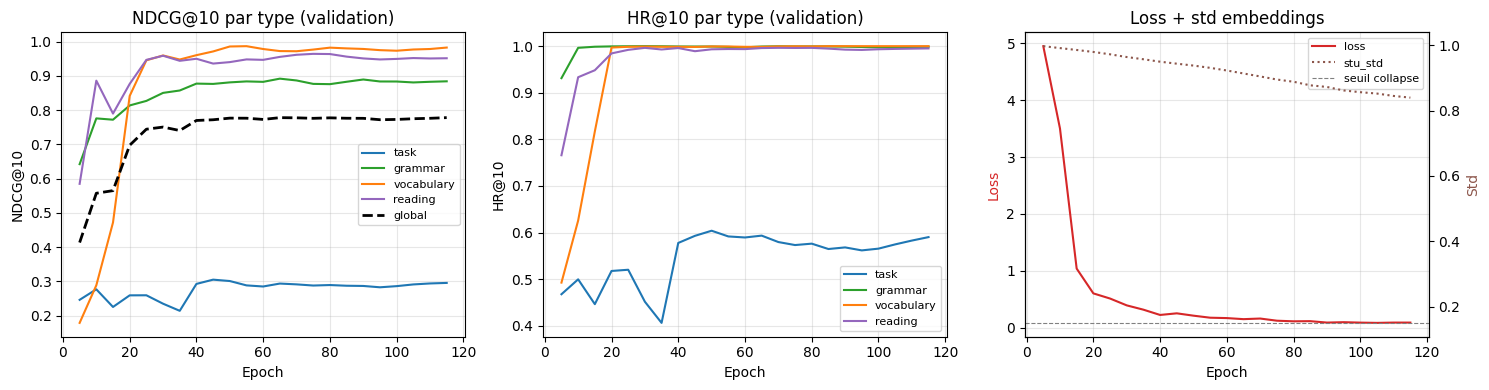

✓ Courbes sauvegardées : checkpoints/learning_curves.png


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# §8. Fonctions utilitaires + Entraînement — CORRECTION VOCABULARY
# ══════════════════════════════════════════════════════════════════════════════

EDGE_MAP = {
    'task'      : ('student', 'attempted',  'task'),
    'grammar'   : ('student', 'practiced',  'grammar'),
    'vocabulary': ('student', 'studied',    'vocabulary'),
    'reading'   : ('student', 'read',       'reading'),
}

EVAL_WEIGHTS = {
    'task': 1.0, 'grammar': 0.5, 'vocabulary': 0.5, 'reading': 0.5
}

NODE_SIZES = {
    'task'      : N_TASK,
    'grammar'   : N_GRAM,
    'vocabulary': N_VOC,
    'reading'   : N_READ,
}

# ── Fonctions utilitaires ─────────────────────────────────────────────────────

def get_student_cefr_by_mode(ei_train, cefr_idx_tensor, N_stu, N_nodes, device=None):
    dev = device if device is not None else cefr_idx_tensor.device
    stu_hist = defaultdict(list)
    for s, a in zip(ei_train[0].tolist(), ei_train[1].tolist()):
        if a < N_nodes:
            stu_hist[s].append(cefr_idx_tensor[a].item())
    stu_cefr = torch.zeros(N_stu, dtype=torch.long, device=dev)
    for s, levels in stu_hist.items():
        stu_cefr[s] = Counter(levels).most_common(1)[0][0]
    return stu_cefr


def bpr_loss_simple(e_stu, h_pos, h_neg, l2=1e-4):
    loss = -F.logsigmoid(
        (e_stu * h_pos).sum(-1) - (e_stu * h_neg).sum(-1)
    ).mean()
    reg = l2 * (
        e_stu.norm(2, -1).pow(2).mean() +
        h_pos.norm(2, -1).pow(2).mean() +
        h_neg.norm(2, -1).pow(2).mean()
    )
    return loss + reg


def uniformity_loss(z, t=2.0):
    z = F.normalize(z, p=2, dim=-1)
    return torch.pdist(z, p=2).pow(2).mul(-t).exp().mean().log()


def neg_sample_for_type(dst, cefr_idx_tensor, stu_cefr_edge, N_nodes):
    neg = torch.randint(0, N_nodes, (dst.shape[0],), device=DEVICE)
    for lvl in range(6):
        mask = (stu_cefr_edge == lvl)
        if mask.sum() == 0:
            continue
        forbidden  = {max(lvl-1, 0), lvl, min(lvl+1, 5)}
        valid_lvls = [l for l in range(6) if l not in forbidden]
        if not valid_lvls:
            neg_pool     = torch.ones(N_nodes, dtype=torch.bool, device=DEVICE)
            neg_pool[dst[mask]] = False
            neg_pool_idx = neg_pool.nonzero(as_tuple=True)[0]
            if len(neg_pool_idx) > 0:
                neg[mask] = neg_pool_idx[
                    torch.randint(len(neg_pool_idx), (mask.sum(),), device=DEVICE)]
            continue
        neg_pool_idx = torch.cat([
            (cefr_idx_tensor == l).nonzero(as_tuple=True)[0]
            for l in valid_lvls
        ])
        if len(neg_pool_idx) > 0:
            neg[mask] = neg_pool_idx[
                torch.randint(len(neg_pool_idx), (mask.sum(),), device=DEVICE)]
    return neg


def build_val_maps(g2_val):
    val_maps = {}
    for node_type, et_key in EDGE_MAP.items():
        if et_key not in g2_val.edge_types:
            val_maps[node_type] = {}
            continue
        ei = g2_val[et_key].edge_index
        m  = defaultdict(list)
        for s, a in zip(ei[0].tolist(), ei[1].tolist()):
            m[s].append(a)
        val_maps[node_type] = dict(m)
    return val_maps


def evaluate_multi(model, kg, g2_dynamic, g2_train, N_stu,
                   val_maps, node_cefr_dict, node_sizes,
                   k=10, n_neg=99):
    model.eval()
    with torch.no_grad():
        h_nodes, e_student = model(kg, g2_dynamic, N_stu)

    std_diag = e_student.std().item()

    ei_train_task = g2_train['student', 'attempted', 'task'].edge_index
    stu_cefr = get_student_cefr_by_mode(
        ei_train_task, node_cefr_dict['task'], N_stu, node_sizes['task'],
        device=DEVICE)

    results   = {}
    all_ndcgs = []

    for node_type, et_key in EDGE_MAP.items():
        val_map = val_maps.get(node_type, {})
        if not val_map:
            continue

        N_nodes   = node_sizes[node_type]
        h_norm    = F.normalize(h_nodes[node_type], p=2, dim=-1)
        all_items = np.arange(N_nodes)

        sample      = list(val_map.keys())
        hits, ndcgs = [], []

        for stu in sample:
            acts = val_map[stu]
            if not acts:
                continue
            pos_item = acts[-1]
            if pos_item >= N_nodes:
                continue

            neg_pool   = np.setdiff1d(all_items, [pos_item])
            neg_sample = np.random.choice(neg_pool, min(n_neg, len(neg_pool)), replace=False)
            candidates = torch.tensor(
                [pos_item] + neg_sample.tolist(),
                dtype=torch.long, device=DEVICE)

            e_u    = F.normalize(e_student[stu].unsqueeze(0), p=2, dim=-1)
            scores = (e_u * h_norm[candidates]).sum(-1)
            ranked = torch.argsort(scores, descending=True).tolist()
            rank   = ranked.index(0) + 1

            hits.append(1 if rank <= k else 0)
            ndcgs.append(1 / np.log2(rank + 1) if rank <= k else 0.0)

        hr   = np.mean(hits)  if hits  else 0.0
        ndcg = np.mean(ndcgs) if ndcgs else 0.0
        results[node_type] = {'HR': hr, 'NDCG': ndcg, 'n': len(hits)}

        all_ndcgs.extend(ndcgs)

    ndcg_global = np.mean(all_ndcgs) if all_ndcgs else 0.0
    hr_task     = results.get('task', {}).get('HR', 0.0)

    return hr_task, ndcg_global, results, std_diag


# ── Préparation des données ───────────────────────────────────────────────────
print('[5/7] Entraînement...')

kg_dev         = kg_adapted.to(DEVICE)
g2_dynamic_dev = g2_dynamic.to(DEVICE)
g2_train_dev   = g2_train.to(DEVICE)
g2_val_dev     = g2_val.to(DEVICE)
g2_test_dev    = g2_test.to(DEVICE)
task_cefr_dev  = task_cefr_idx.to(DEVICE)
gram_cefr_dev  = gram_cefr_idx.to(DEVICE)
voc_cefr_dev   = voc_cefr_idx.to(DEVICE)
read_cefr_dev  = read_cefr_idx.to(DEVICE)

node_cefr_dict_dev = {
    'task'      : task_cefr_dev,
    'grammar'   : gram_cefr_dev,
    'vocabulary': voc_cefr_dev,
    'reading'   : read_cefr_dev,
}

ei_tr              = g2_train_dev['student', 'attempted', 'task'].edge_index
src_task           = ei_tr[0]
dst_task           = ei_tr[1].clamp(max=N_TASK - 1)
stu_cefr_train     = get_student_cefr_by_mode(ei_tr, task_cefr_dev, N_STU, N_TASK)
stu_cefr_edge_task = stu_cefr_train[src_task]

ei_tr_gram   = g2_train_dev['student', 'practiced',  'grammar'].edge_index
ei_tr_voc    = g2_train_dev['student', 'studied',    'vocabulary'].edge_index
ei_tr_read   = g2_train_dev['student', 'read',       'reading'].edge_index
n_task_edges = src_task.shape[0]

val_maps_all = build_val_maps(g2_val_dev)
print(f'  Val maps construites :')
for nt, m in val_maps_all.items():
    print(f'    {nt:12s} : {len(m)} étudiants')

# ── Hyperparamètres ───────────────────────────────────────────────────────────
BATCH_SIZE   = 4096
LR           = 0.0018844973128841452
PATIENCE     = 10
EPOCHS       = 200
EVAL_EVERY   = 5
GRAD_CLIP    = 1.0
MULTI_W_GRAM = 0.5
MULTI_W_VOC  = 1.0
MULTI_W_READ = 0.5
BS_GRAM      = BATCH_SIZE // 4
BS_VOC       = BATCH_SIZE // 2
BS_READ      = BATCH_SIZE // 4
UNIF_W       = 0.06776612817421043
UNIF_SAMPLE  = 1024

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=8.20049529731146e-06
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5, min_lr=1e-6)

torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
np.random.seed(42)

os.makedirs('checkpoints', exist_ok=True)
best_hr, best_ndcg, best_state, patience_cnt = 0.0, 0.0, None, 0
history = []

print(f'  Device={DEVICE} | lr={LR} | batch={BATCH_SIZE}')
print(f'  BS_GRAM={BS_GRAM} | BS_VOC={BS_VOC} | BS_READ={BS_READ}')
print('\n  ════════ Meilleurs hyperparamètres Optuna ════════')
print(f'  lr           = {LR:.10f}')
print(f'  weight_decay = 8.20049529731146e-06')
print(f'  unif_weight  = {UNIF_W:.10f}')
print(f'  mu           = 0.01697884130961766')
print(f'  hidden_dim=128 | heads=8 | out_dim=128 | dropout=0.4')
print('  ══════════════════════════════════════════════════')
print('─' * 70)

# ── Boucle d'entraînement ─────────────────────────────────────────────────────
for epoch in range(EPOCHS):
    model.train()
    optimizer.zero_grad()

    # ── Task batch ───────────────────────────────────────────────────────────
    idx_b  = torch.randint(0, n_task_edges, (BATCH_SIZE,), device=DEVICE)
    src_b  = src_task[idx_b]
    dst_b  = dst_task[idx_b]
    cefr_b = stu_cefr_edge_task[idx_b]
    neg_b  = neg_sample_for_type(dst_b, task_cefr_dev, cefr_b, N_TASK)

    h_nodes, e_student = model(kg_dev, g2_dynamic_dev, N_STU)

    loss = bpr_loss_simple(e_student[src_b],
                           h_nodes['task'][dst_b],
                           h_nodes['task'][neg_b])

    # ── Grammar batch ────────────────────────────────────────────────────────
    if ei_tr_gram.shape[1] > 0:
        idx_g = torch.randint(0, ei_tr_gram.shape[1], (BS_GRAM,), device=DEVICE)
        src_g = ei_tr_gram[0][idx_g]
        dst_g = ei_tr_gram[1][idx_g].clamp(max=N_GRAM - 1)
        neg_g = neg_sample_for_type(dst_g, gram_cefr_dev, stu_cefr_train[src_g], N_GRAM)
        loss  = loss + MULTI_W_GRAM * bpr_loss_simple(
            e_student[src_g], h_nodes['grammar'][dst_g], h_nodes['grammar'][neg_g])

    # ── Vocabulary batch ─────────────────────────────────────────────────────
    if ei_tr_voc.shape[1] > 0:
        idx_v = torch.randint(0, ei_tr_voc.shape[1], (BS_VOC,), device=DEVICE)
        src_v = ei_tr_voc[0][idx_v]
        dst_v = ei_tr_voc[1][idx_v].clamp(max=N_VOC - 1)
        neg_v = torch.randint(0, N_VOC, (BS_VOC,), device=DEVICE)
        loss  = loss + MULTI_W_VOC * bpr_loss_simple(
            e_student[src_v], h_nodes['vocabulary'][dst_v], h_nodes['vocabulary'][neg_v])

    # ── Reading batch ────────────────────────────────────────────────────────
    if ei_tr_read.shape[1] > 0:
        idx_r = torch.randint(0, ei_tr_read.shape[1], (BS_READ,), device=DEVICE)
        src_r = ei_tr_read[0][idx_r]
        dst_r = ei_tr_read[1][idx_r].clamp(max=N_READ - 1)
        neg_r = neg_sample_for_type(dst_r, read_cefr_dev, stu_cefr_train[src_r], N_READ)
        loss  = loss + MULTI_W_READ * bpr_loss_simple(
            e_student[src_r], h_nodes['reading'][dst_r], h_nodes['reading'][neg_r])

    # ── Uniformity loss ──────────────────────────────────────────────────────
    perm = torch.randperm(N_STU, device=DEVICE)[:UNIF_SAMPLE]
    loss = loss + UNIF_W * uniformity_loss(e_student[perm])

    # ── Régularisation mu ────────────────────────────────────────────────────
    MU_TRAIN = 0.01697884130961766
    loss = loss + MU_TRAIN * e_student.norm(2, dim=-1).mean()

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
    optimizer.step()

    # ── Évaluation ───────────────────────────────────────────────────────────
    if (epoch + 1) % EVAL_EVERY == 0:

        hr_task, ndcg_global, res_per_type, std_diag = evaluate_multi(
            model, kg_dev, g2_dynamic_dev, g2_train_dev,
            N_STU, val_maps_all, node_cefr_dict_dev,
            NODE_SIZES, k=10)

        scheduler.step(ndcg_global)

        history.append({
            'epoch'      : epoch + 1,
            'loss'       : loss.item(),
            'HR@10_task' : hr_task,
            'NDCG_global': ndcg_global,
            'stu_std'    : std_diag,
            **{f'NDCG_{t}': v['NDCG'] for t, v in res_per_type.items()},
            **{f'HR_{t}'  : v['HR']   for t, v in res_per_type.items()},
        })

        if ndcg_global > best_ndcg + 1e-4:
            best_hr      = hr_task
            best_ndcg    = ndcg_global
            best_state   = copy.deepcopy(model.state_dict())
            patience_cnt = 0
            torch.save(best_state, 'checkpoints/best_hier_gnn_v3.pt')
            tag = '✅'
        else:
            patience_cnt += 1
            tag = ''

        lr_cur = optimizer.param_groups[0]['lr']
        print(f'  Epoch {epoch+1:3d} — NDCG={ndcg_global:.4f}  std={std_diag:.4f}  lr={lr_cur:.1e} {tag}')

        if patience_cnt >= PATIENCE:
            print(f'  ⏹ Early stopping epoch {epoch+1}  '
                  f'(best NDCG_global={best_ndcg:.4f})')
            break

# ── Chargement meilleur état ──────────────────────────────────────────────────
if best_state:
    model.load_state_dict(best_state)

model.eval()
with torch.no_grad():
    h_nodes, e_student = model(kg_dev, g2_dynamic_dev, N_STU)

# ── Résumé final ──────────────────────────────────────────────────────────────
print(f'\n✓ Entraînement terminé')
print(f'  best_val_HR@10_task  : {best_hr:.4f}')
print(f'  best_val_NDCG_global : {best_ndcg:.4f}')
std_final = e_student.std().item()
print(f'  Student emb std      : {std_final:.4f}',
      '✅' if std_final > 0.15 else '⚠ collapse → augmenter UNIF_W')

# ── Courbes d'apprentissage ───────────────────────────────────────────────────
if history:
    df_hist = pd.DataFrame(history).set_index('epoch')
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    colors = {'task': '#1f77b4', 'grammar': '#2ca02c',
              'vocabulary': '#ff7f0e', 'reading': '#9467bd'}

    ax = axes[0]
    for t, c in colors.items():
        col = f'NDCG_{t}'
        if col in df_hist.columns:
            ax.plot(df_hist.index, df_hist[col], label=t, color=c, linewidth=1.5)
    ax.plot(df_hist.index, df_hist['NDCG_global'],
            label='global', color='black', linewidth=2, linestyle='--')
    ax.set_title('NDCG@10 par type (validation)')
    ax.set_xlabel('Epoch'); ax.set_ylabel('NDCG@10')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    ax = axes[1]
    for t, c in colors.items():
        col = f'HR_{t}'
        if col in df_hist.columns:
            ax.plot(df_hist.index, df_hist[col], label=t, color=c, linewidth=1.5)
    ax.set_title('HR@10 par type (validation)')
    ax.set_xlabel('Epoch'); ax.set_ylabel('HR@10')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    ax = axes[2]
    ax2 = ax.twinx()
    ax.plot(df_hist.index, df_hist['loss'],     color='#d62728', linewidth=1.5, label='loss')
    ax2.plot(df_hist.index, df_hist['stu_std'], color='#8c564b',
             linewidth=1.5, linestyle=':', label='stu_std')
    ax2.axhline(0.15, color='gray', linestyle='--', linewidth=0.8, label='seuil collapse')
    ax.set_title('Loss + std embeddings')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss', color='#d62728')
    ax2.set_ylabel('Std',  color='#8c564b')
    lines1, labs1 = ax.get_legend_handles_labels()
    lines2, labs2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labs1 + labs2, fontsize=8)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('checkpoints/learning_curves.png', dpi=150)
    plt.show()
    print('✓ Courbes sauvegardées : checkpoints/learning_curves.png')

## §9. Évaluation finale

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# §9. Évaluation finale — RÉSULTAT GLOBAL UNIQUE
#     Métriques : Precision@k, Recall@k, NDCG@k, HR@k, MRR
#     + Coverage, CEFR_Accuracy, Cold/Warm Start
#     Protocole : LOO + 99 négatifs (même protocole tous types)
# ══════════════════════════════════════════════════════════════════════

print('[6/7] Évaluation finale...')
np.random.seed(42)


def compute_all_metrics_global(e_student, h_nodes,
                                g2_test, g2_train,
                                node_sizes, node_cefr_dict,
                                n_neg=99, k_list=[5, 10]):
    """
    Un seul résultat global — tous types confondus.
    Protocole LOO + 99 négatifs.
    """

    # ── Niveau CEFR de chaque étudiant ───────────────────────────────
    ei_tr_task = g2_train['student', 'attempted', 'task'].edge_index
    stu_cefr   = get_student_cefr_by_mode(
        ei_tr_task,
        node_cefr_dict['task'].to(DEVICE),
        e_student.shape[0],
        node_sizes['task'],
        device=DEVICE
    )

    # ── Nb interactions train par étudiant (cold vs warm) ────────────
    stu_n_train = defaultdict(int)
    for s in ei_tr_task[0].tolist():
        stu_n_train[s] += 1

    # ── Initialisation résultats globaux ─────────────────────────────
    all_results = {k: {
        'precision': [], 'recall': [],
        'ndcg'     : [], 'hr'    : [], 'mrr': [],
        'cefr_acc' : [],
        'cold_hr'  : [], 'cold_ndcg': [],
        'warm_hr'  : [], 'warm_ndcg': [],
    } for k in k_list}

    items_recommended = set()
    total_items       = 0
    n_cold_total      = 0
    n_warm_total      = 0

    for node_type, et_key in EDGE_MAP.items():

        N_nodes  = node_sizes[node_type]
        h_norm   = F.normalize(h_nodes[node_type], p=2, dim=-1)
        cefr_t   = node_cefr_dict[node_type].to(DEVICE)
        ei_test  = g2_test[et_key].edge_index
        total_items += N_nodes

        # ── Ground truth LOO ─────────────────────────────────────────
        stu_pos = {}
        for s, a in zip(ei_test[0].tolist(), ei_test[1].tolist()):
            if a < N_nodes:
                stu_pos[s] = a   # dernier ← ground truth

        all_items = np.arange(N_nodes)

        for stu, pos_item in stu_pos.items():

            # ── 99 négatifs aléatoires ────────────────────────────────
            neg_pool   = np.setdiff1d(all_items, [pos_item])
            neg_sample = np.random.choice(neg_pool, n_neg, replace=False)

            candidates = torch.tensor(
                [pos_item] + neg_sample.tolist(),
                dtype=torch.long, device=DEVICE)

            # ── Score cosinus ─────────────────────────────────────────
            e_u    = F.normalize(e_student[stu].unsqueeze(0), p=2, dim=-1)
            scores = (e_u * h_norm[candidates]).sum(-1)
            ranked = torch.argsort(scores, descending=True).tolist()
            rank   = ranked.index(0) + 1

            is_cold = stu_n_train[stu] <= 1

            for k in k_list:

                top_k_indices = ranked[:k]
                top_k_items   = candidates[
                    torch.tensor(top_k_indices)].tolist()
                hits   = [1 if idx == 0 else 0 for idx in top_k_indices]
                n_hits = sum(hits)

                # ── Precision@k = hits / k ────────────────────────────
                precision = n_hits / k

                # ── Recall@k = hits / n_positifs ──────────────────────
                recall = n_hits / 1

                # ── DCG / IDCG / NDCG ─────────────────────────────────
                dcg  = sum(h / np.log2(i+2) for i, h in enumerate(hits))
                idcg = 1.0 / np.log2(2)
                ndcg = dcg / idcg if idcg > 0 else 0.0

                # ── HR@k ──────────────────────────────────────────────
                hr = 1.0 if rank <= k else 0.0

                # ── MRR ───────────────────────────────────────────────
                mrr = 1.0 / rank if rank <= k else 0.0

                # ── Coverage ──────────────────────────────────────────
                items_recommended.update(top_k_items)

                # ── CEFR Accuracy ─────────────────────────────────────
                stu_lvl      = stu_cefr[stu].item()
                allowed_cefr = {
                    max(stu_lvl-1, 0),
                    stu_lvl,
                    min(stu_lvl+1, 5)
                }
                cefr_items = cefr_t[
                    torch.tensor(top_k_items, device=DEVICE)
                ].tolist()
                cefr_acc = sum(
                    1 for c in cefr_items if c in allowed_cefr
                ) / k

                # ── Cold / Warm ───────────────────────────────────────
                if is_cold:
                    all_results[k]['cold_hr'].append(hr)
                    all_results[k]['cold_ndcg'].append(ndcg)
                else:
                    all_results[k]['warm_hr'].append(hr)
                    all_results[k]['warm_ndcg'].append(ndcg)

                # ── Stockage global ───────────────────────────────────
                all_results[k]['precision'].append(precision)
                all_results[k]['recall'].append(recall)
                all_results[k]['ndcg'].append(ndcg)
                all_results[k]['hr'].append(hr)
                all_results[k]['mrr'].append(mrr)
                all_results[k]['cefr_acc'].append(cefr_acc)

            if is_cold:
                n_cold_total += 1
            else:
                n_warm_total += 1

    # ── Agrégation finale globale ─────────────────────────────────────
    out = {}
    for k in k_list:
        r = all_results[k]
        out[f'Precision@{k}']  = np.mean(r['precision']) if r['precision'] else 0.0
        out[f'Recall@{k}']     = np.mean(r['recall'])    if r['recall']    else 0.0
        out[f'NDCG@{k}']       = np.mean(r['ndcg'])      if r['ndcg']      else 0.0
        out[f'HR@{k}']         = np.mean(r['hr'])         if r['hr']        else 0.0
        out[f'MRR@{k}']        = np.mean(r['mrr'])        if r['mrr']       else 0.0
        out[f'CEFR_Acc@{k}']   = np.mean(r['cefr_acc']) if r['cefr_acc']  else 0.0
        out[f'Cold_HR@{k}']    = np.mean(r['cold_hr'])   if r['cold_hr']   else 0.0
        out[f'Cold_NDCG@{k}']  = np.mean(r['cold_ndcg'])if r['cold_ndcg'] else 0.0
        out[f'Warm_HR@{k}']    = np.mean(r['warm_hr'])   if r['warm_hr']   else 0.0
        out[f'Warm_NDCG@{k}']  = np.mean(r['warm_ndcg'])if r['warm_ndcg'] else 0.0
        out[f'n_total@{k}']    = len(r['hr'])

    out['Coverage']    = len(items_recommended) / total_items
    out['n_cold']      = n_cold_total
    out['n_warm']      = n_warm_total

    return out


# ── Lancement ─────────────────────────────────────────────────────────
metrics = compute_all_metrics_global(
    e_student, h_nodes,
    g2_test_dev, g2_train_dev,
    NODE_SIZES, node_cefr_dict_dev,
    n_neg=99, k_list=[5, 10]
)

# ── Affichage — un seul tableau global ───────────────────────────────
n       = int(metrics.get('n_total@10', 0))
n_cold  = int(metrics.get('n_cold', 0))
n_warm  = int(metrics.get('n_warm', 0))

print(f'\n{"="*55}')
print('RÉSULTATS FINAUX — HIER-GNN')
print(f'{"="*55}')
print(f'  {"Métrique":20s} | {"K=5":>10} | {"K=10":>10}')
print(f'  {"-"*48}')

# Ranking
print(f'  --- Ranking ---')
for metric in ['Precision', 'Recall', 'NDCG', 'HR', 'MRR']:
    v5  = metrics.get(f'{metric}@5',  0.0)
    v10 = metrics.get(f'{metric}@10', 0.0)
    print(f'  {metric:20s} | {v5:>10.4f} | {v10:>10.4f}')

# Qualité pédagogique
print(f'  --- Qualité pédagogique ---')
v5  = metrics.get('CEFR_Acc@5',  0.0)
v10 = metrics.get('CEFR_Acc@10', 0.0)
print(f'  {"CEFR_Accuracy":20s} | {v5:>10.4f} | {v10:>10.4f}')
cov = metrics.get('Coverage', 0.0)
print(f'  {"Coverage":20s} | {cov:>10.4f} | {cov:>10.4f}')

# Cold vs Warm
print(f'  --- Cold Start ({n_cold:,} cold | {n_warm:,} warm) ---')
for split in ['Cold', 'Warm']:
    for metric in ['HR', 'NDCG']:
        v5  = metrics.get(f'{split}_{metric}@5',  0.0)
        v10 = metrics.get(f'{split}_{metric}@10', 0.0)
        print(f'  {split+"_"+metric:20s} | {v5:>10.4f} | {v10:>10.4f}')

print(f'  {"-"*48}')
print(f'  {"N évaluations":20s} | {n:>10,}')
print(f'{"="*55}')

[6/7] Évaluation finale...

RÉSULTATS FINAUX — HIER-GNN
  Métrique             |        K=5 |       K=10
  ------------------------------------------------
  --- Ranking ---
  Precision            |     0.1678 |     0.0894
  Recall               |     0.8388 |     0.8937
  NDCG                 |     0.7675 |     0.7851
  HR                   |     0.8388 |     0.8937
  MRR                  |     0.7434 |     0.7505
  --- Qualité pédagogique ---
  CEFR_Accuracy        |     0.9678 |     0.9440
  Coverage             |     0.3788 |     0.3788
  --- Cold Start (89,971 cold | 116,784 warm) ---
  Cold_HR              |     0.8749 |     0.9319
  Cold_NDCG            |     0.8025 |     0.8208
  Warm_HR              |     0.8110 |     0.8643
  Warm_NDCG            |     0.7406 |     0.7576
  ------------------------------------------------
  N évaluations        |    206,755


## §10. Recommandation Multi-Types (task + grammar + vocabulary + reading)

In [ ]:
def temperature_scaled_cosine(e_u, h_cands, temperature=0.1):
    e_norm = F.normalize(e_u, p=2, dim=-1)
    h_norm = F.normalize(h_cands, p=2, dim=-1)
    return (e_norm * h_norm).sum(-1) / temperature


act_to_task_loaded = torch.load(BASE + 'act_to_task.pt', map_location='cpu')

# ── FIX task_to_act : garder toutes les activités par task ───────────
task_to_acts = defaultdict(list)
for a, t in enumerate(act_to_task_loaded):
    task_to_acts[t.item()].append(a)

EDGE_MAP = {
    'task'      : ('student', 'attempted',  'task'),
    'grammar'   : ('student', 'practiced',  'grammar'),
    'vocabulary': ('student', 'studied',    'vocabulary'),
    'reading'   : ('student', 'read',       'reading'),
}
TYPE_EMOJI = {
    'task': '📋', 'grammar': '📚', 'vocabulary': '🔤', 'reading': '📖'
}
NODE_SIZES = {
    'task': N_TASK, 'grammar': N_GRAM,
    'vocabulary': N_VOC, 'reading': N_READ
}


def recommend_multi(student_idx, e_student, h_nodes, node_cefr_dict,
                    g2_dynamic, g2_train, k=10, temperature=0.1):

    # ── FIX CEFR : utiliser train + dynamic pour cold users ──────────
    ei_dyn  = g2_dynamic['student', 'attempted', 'task'].edge_index
    ei_tr   = g2_train['student',   'attempted', 'task'].edge_index

    tasks_dyn = ei_dyn[1, ei_dyn[0] == student_idx].tolist()
    tasks_tr  = ei_tr[1,  ei_tr[0]  == student_idx].tolist()
    all_tasks = tasks_dyn + tasks_tr

    levels = [
        node_cefr_dict['task'][t].item()
        for t in all_tasks if t < N_TASK
    ]

    # Si cold user (aucun historique) → utiliser features statiques
    if levels:
        level_idx = Counter(levels).most_common(1)[0][0]
    else:
        # Cold user → niveau A1 par défaut (0)
        level_idx = 0

    level   = CEFR_ORDER[level_idx]
    allowed = {
        max(level_idx-1, 0),
        level_idx,
        min(level_idx+1, len(CEFR_ORDER)-1)
    }

    # ── Collecter candidats par type ──────────────────────────────────
    buckets = {}

    for node_type, h_node in h_nodes.items():
        cefr_idx = node_cefr_dict[node_type].to(DEVICE)
        N_nodes  = NODE_SIZES[node_type]
        et_key   = EDGE_MAP[node_type]

        # ── Filtrage CEFR ─────────────────────────────────────────────
        mask = torch.zeros(N_nodes, dtype=torch.bool, device=DEVICE)
        for lvl in allowed:
            mask |= (cefr_idx == lvl)

        # ── FIX exclusion : dynamic ET train séparément ───────────────
        for split_graph in [g2_dynamic, g2_train]:
            if et_key in split_graph.edge_types:
                ei   = split_graph[et_key].edge_index
                done = set(ei[1, ei[0] == student_idx].tolist())
                for d in done:
                    if d < N_nodes:
                        mask[d] = False

        candidates = mask.nonzero(as_tuple=True)[0]
        if len(candidates) == 0:
            buckets[node_type] = []
            continue

        # ── Score cosinus avec température ────────────────────────────
        e_u    = e_student[student_idx].unsqueeze(0).expand(
            len(candidates), -1)
        scores = temperature_scaled_cosine(
            e_u, h_node[candidates], temperature)

        # ── Normalisation min-max par type ────────────────────────────
        if len(scores) > 1:
            s_min, s_max = scores.min(), scores.max()
            if s_max > s_min:
                scores = (scores - s_min) / (s_max - s_min)
            else:
                scores = torch.zeros_like(scores)

        bucket = [
            (score, node_type, c_idx)
            for c_idx, score in zip(candidates.tolist(), scores.tolist())
        ]
        bucket.sort(key=lambda x: -x[0])
        buckets[node_type] = bucket

    # ── Quota minimal garanti par type ────────────────────────────────
    QUOTA = {
        'task'      : 2,
        'grammar'   : 2,
        'vocabulary': 4,
        'reading'   : 2,
    }

    top_k = []
    used  = set()

    # Étape 1 — remplir les quotas
    for node_type, quota in QUOTA.items():
        added = 0
        for item in buckets.get(node_type, []):
            if added >= quota:
                break
            key = (item[1], item[2])
            if key not in used:
                top_k.append(item)
                used.add(key)
                added += 1

    # Étape 2 — compléter jusqu'à k avec meilleurs scores restants
    all_remaining = []
    for node_type, bucket in buckets.items():
        for item in bucket:
            key = (item[1], item[2])
            if key not in used:
                all_remaining.append(item)

    all_remaining.sort(key=lambda x: -x[0])
    for item in all_remaining:
        if len(top_k) >= k:
            break
        key = (item[1], item[2])
        if key not in used:
            top_k.append(item)
            used.add(key)

    # Tri final par score
    top_k.sort(key=lambda x: -x[0])

    # ── Construction résultats ────────────────────────────────────────
    results = []
    for rank, (score, node_type, node_id) in enumerate(top_k):
        cefr_lvl = CEFR_ORDER[node_cefr_dict[node_type][node_id].item()]

        # ── FIX task_to_act : retourner toutes les activités ─────────
        if node_type == 'task':
            act_ids = task_to_acts.get(node_id, ['—'])
            act_id  = act_ids[0] if act_ids else '—'
        else:
            act_id = '—'

        results.append({
            'rank'       : rank + 1,
            'emoji'      : TYPE_EMOJI[node_type],
            'type'       : node_type,
            'node_id'    : node_id,
            'activity_id': act_id,
            'cefr'       : cefr_lvl,
            'score'      : round(float(score), 4),
        })

    return results, level


print('✓ Fonction recommend_multi corrigée :')
print('  - CEFR : train + dynamic (cold users gérés)')
print('  - Exclusion historique : dynamic ET train séparément')
print('  - task_to_acts : toutes activités par task')

✓ Fonction recommend_multi corrigée :
  - CEFR : train + dynamic (cold users gérés)
  - Exclusion historique : dynamic ET train séparément
  - task_to_acts : toutes activités par task


## §11. Exemples de recommandations multi-types

In [ ]:
print('[7/7] Exemples de recommandations multi-types...\n')

ei_dyn = g2_dynamic_dev['student', 'attempted', 'task'].edge_index
inter_per_stu = torch.bincount(ei_dyn[0], minlength=N_STU)
rich_students = inter_per_stu.argsort(descending=True)[:4].tolist()
print(f'Apprenants sélectionnés (les plus actifs) : {rich_students}\n')

for STUDENT_IDX in rich_students:
    recs, level = recommend_multi(
        student_idx    = STUDENT_IDX,
        e_student      = e_student,
        h_nodes        = h_nodes,
        node_cefr_dict = node_cefr_dict_dev,
        g2_dynamic     = g2_dynamic_dev,
        g2_train       = g2_train_dev,
        k              = 10,
        temperature    = 0.1,
    )
    if not recs:
        print(f'  Apprenant #{STUDENT_IDX} : aucune recommandation\n')
        continue

    print('=' * 70)
    print(f'RECOMMANDATIONS — Apprenant #{STUDENT_IDX} (niveau {level})')
    print(f'  Interactions dans historique : {inter_per_stu[STUDENT_IDX].item()}')
    print('=' * 70)

    df = pd.DataFrame(recs)
    df['label'] = df['emoji'] + ' ' + df['type']
    print(df[['rank', 'label', 'node_id', 'activity_id', 'cefr', 'score']]
          .to_string(index=False))

    print('\n  Répartition :')
    for nt, emoji in TYPE_EMOJI.items():
        count = sum(1 for r in recs if r['type'] == nt)
        if count > 0:
            print(f'    {emoji} {nt:12s}: {count}')

    # ── Historique tasks ──────────────────────────────────────────────
    ei   = g2_dynamic_dev['student', 'attempted', 'task'].edge_index
    ea   = g2_dynamic_dev['student', 'attempted', 'task'].edge_attr
    mask_s = (ei[0] == STUDENT_IDX)

    if mask_s.sum() > 0:
        tasks_done = ei[1, mask_s].tolist()
        tw_done    = ea[mask_s, 1].tolist()
        print(f'\n  Historique tasks ({len(tasks_done)} récentes) :')
        for t, tw in sorted(zip(tasks_done, tw_done),
                            key=lambda x: -x[1])[:5]:
            # ── FIX : utiliser task_to_acts ──────────────────────────
            acts = task_to_acts.get(t, ['?'])
            act  = acts[0] if acts else '?'
            lvl  = CEFR_ORDER[task_cefr_dev[t].item()]
            print(f'    📋 task {t:3d} (act {str(act):3s}) '
                  f'— {lvl} — tw={tw:.4f}')
    print()

[7/7] Exemples de recommandations multi-types...

Apprenants sélectionnés (les plus actifs) : [74300, 74210, 74218, 13107]

RECOMMANDATIONS — Apprenant #74300 (niveau A1)
  Interactions dans historique : 20
 rank        label  node_id activity_id cefr  score
    1       📋 task       41          60   A2 1.0000
    2    📚 grammar       19           —   A2 1.0000
    3 🔤 vocabulary     7297           —   A1 1.0000
    4    📖 reading     2478           —   A1 1.0000
    5    📚 grammar       23           —   A2 0.9921
    6 🔤 vocabulary      244           —   A1 0.9843
    7 🔤 vocabulary      159           —   A1 0.9721
    8 🔤 vocabulary      149           —   A1 0.9569
    9    📖 reading     4819           —   A1 0.9337
   10       📋 task       43          62   A2 0.7965

  Répartition :
    📋 task        : 2
    📚 grammar     : 2
    🔤 vocabulary  : 4
    📖 reading     : 2

  Historique tasks (20 récentes) :
    📋 task  33 (act 36 ) — A2 — tw=0.2323
    📋 task  40 (act 81 ) — A2 — tw=0.2